#Matplotlib

In [4]:
import matplotlib.pyplot as plt
import numpy as np

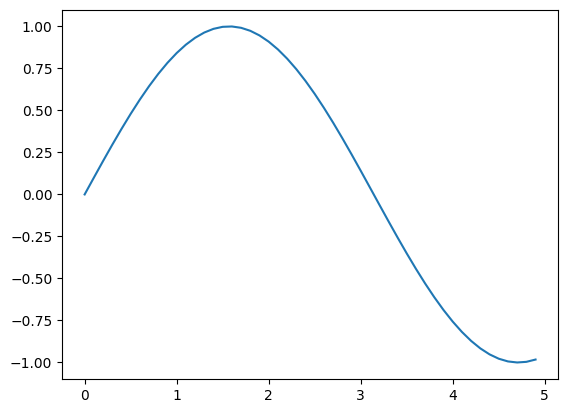

In [6]:
#plot de 0 a 5, dibujando cada .1 el seno de x
#arange lo que hace es crear una lista de valores de "a" a "b" con saltos de "c"
#arange(a,b,c)
x=np.arange(0,5,.1)
y= np.sin(x)
plt.plot(x,y)

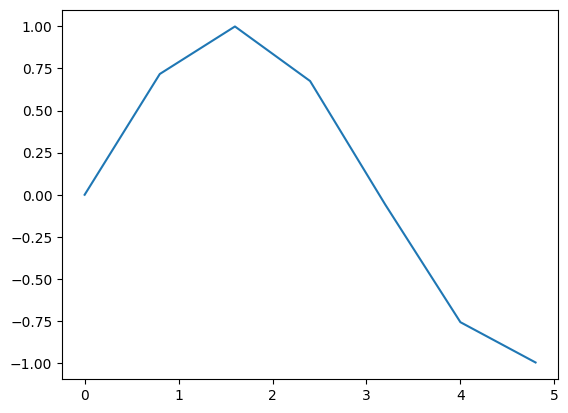

In [11]:
# si cambiamos el .1 se vuelve mucho más recto
x=np.arange(0,5,.8)
y= np.sin(x)
plt.plot(x,y)

#Plotting

En matplot existen muchas gráficas:

https://matplotlib.org/stable/plot_types/basic/

##Plot linear

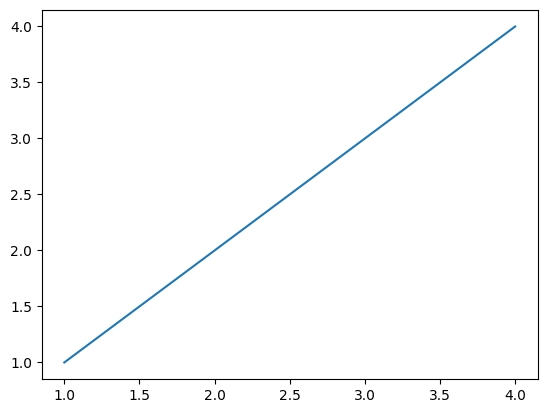

In [15]:
x = [1,2,3,4]
y =[1,2,3,4]
plt.plot(x,y)
#El show elimina el texto del plot parecido a [<matplotlib.lines.Line2D at 0x7a6f6a605d10>]
#Jupyter llama el show por default al final del documento
plt.show()

###Plots de datos

In [2]:
import pandas as pd
from datasets import load_dataset
ds = load_dataset("lukebarousse/data_jobs")

df = ds["train"].to_pandas()

df.head(1)

README.md:   0%|          | 0.00/3.25k [00:00<?, ?B/s]

data_jobs.csv: reconstructing file:   0%|          |  0.00B /  231MB            

data_jobs.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   job_title_short        785741 non-null  object 
 1   job_title              785740 non-null  object 
 2   job_location           784696 non-null  object 
 3   job_via                785733 non-null  object 
 4   job_schedule_type      773074 non-null  object 
 5   job_work_from_home     785741 non-null  bool   
 6   search_location        785741 non-null  object 
 7   job_posted_date        785741 non-null  object 
 8   job_no_degree_mention  785741 non-null  bool   
 9   job_health_insurance   785741 non-null  bool   
 10  job_country            785692 non-null  object 
 11  salary_rate            33067 non-null   object 
 12  salary_year_avg        22003 non-null   float64
 13  salary_hour_avg        10662 non-null   float64
 14  company_name           785723 non-nu

In [17]:
df['job_posted_date'] = pd.to_datetime(df["job_posted_date"])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

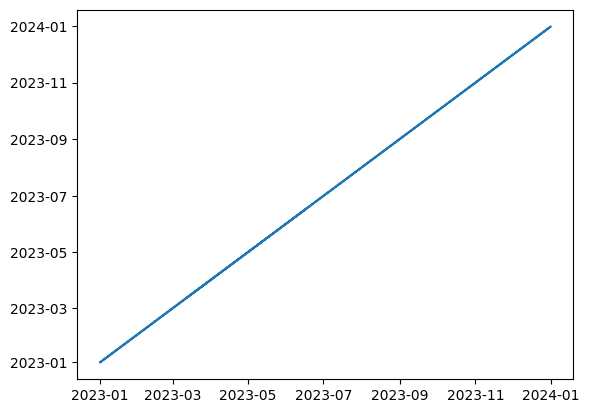

In [19]:
plt.plot(df.job_posted_date, df.job_posted_date)
plt.show()

In [27]:
date_counts = df.job_posted_date.value_counts()
#El siguiente sort nos sirve para ordenar las fechas
date_counts = date_counts.sort_index()

In [25]:
date_counts

,count
job_posted_date,
2023-01-01 00:00:04,1
2023-01-01 00:00:07,1
2023-01-01 00:00:22,1
2023-01-01 00:00:24,1
2023-01-01 00:00:27,1
...,...
2023-12-31 23:40:18,2
2023-12-31 23:40:22,2
2023-12-31 23:40:31,2


#Esto se ve terrible porque las fechas están a unos segundos la una de la otra.

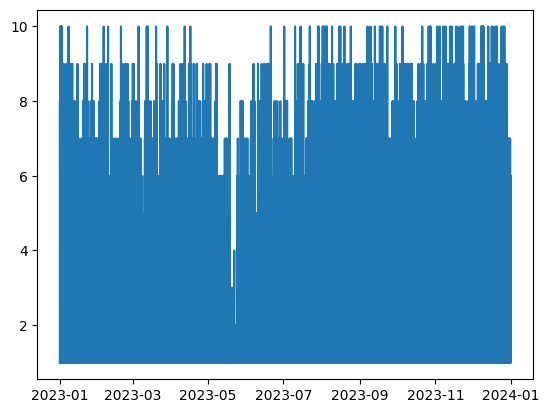

In [26]:
plt.plot(date_counts.index, date_counts)
plt.show()

Vamos a simplificar esto con una columna adicional

In [28]:
df["job_posted_month"] = df["job_posted_date"].dt.month

In [37]:
monthly_counts = df.job_posted_month.value_counts()
monthly_counts = monthly_counts.sort_index()

monthly_counts

,count
job_posted_month,
1,91822
2,64578
3,64084
4,62919
5,52104
6,61572
7,63777
8,75162
9,62359


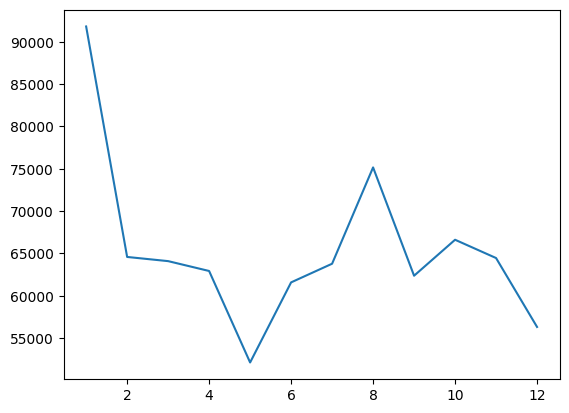

In [39]:
plt.plot(monthly_counts.index, monthly_counts.values)

##Series vs DataFrame

Pandas tiene series además de dataframes.

Una serie es básicamente una lista.

In [45]:
serie = pd.Series([10,25,30,45,50], index=["a","b","c","d","e"])
serie

,0
a,10
b,25
c,30
d,45
e,50


In [46]:
serie.index

Index(['a', 'b', 'c', 'd', 'e'], dtype='object')

In [47]:
serie.values

array([10, 25, 30, 45, 50])

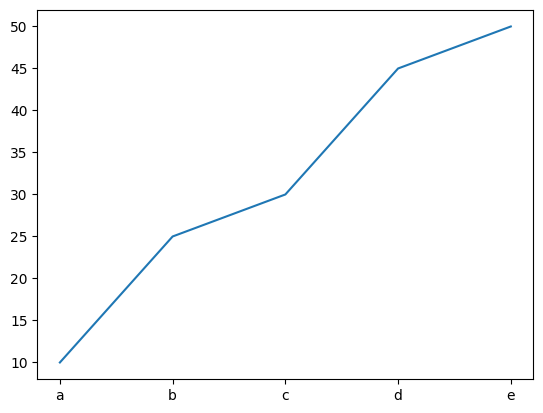

In [48]:
plt.plot(serie.index, serie.values)

#Bar Charts:

In [49]:
df.job_title_short.value_counts()

,count
job_title_short,
Data Analyst,196075
Data Engineer,186241
Data Scientist,172286
Business Analyst,49063
Software Engineer,44929
Senior Data Engineer,44563
Senior Data Scientist,36957
Senior Data Analyst,29216
Machine Learning Engineer,14080


In [51]:
job_title_counts = df.job_title_short.value_counts()

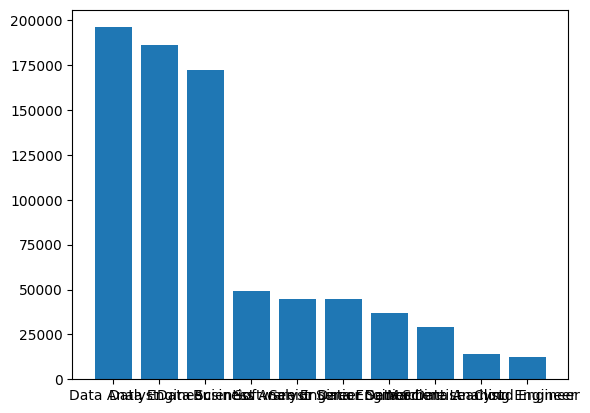

In [73]:
plt.bar(job_title_counts.index, job_title_counts.values)
plt.show()

<BarContainer object of 10 artists>

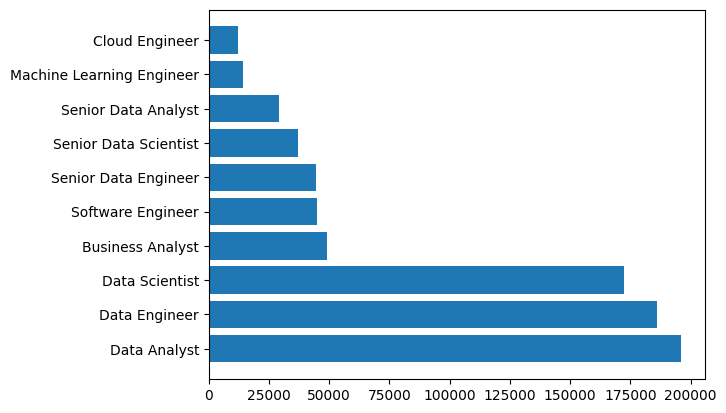

In [53]:
plt.barh(job_title_counts.index, job_title_counts.values)

#Labeling

xticks nos permite rotar las labels

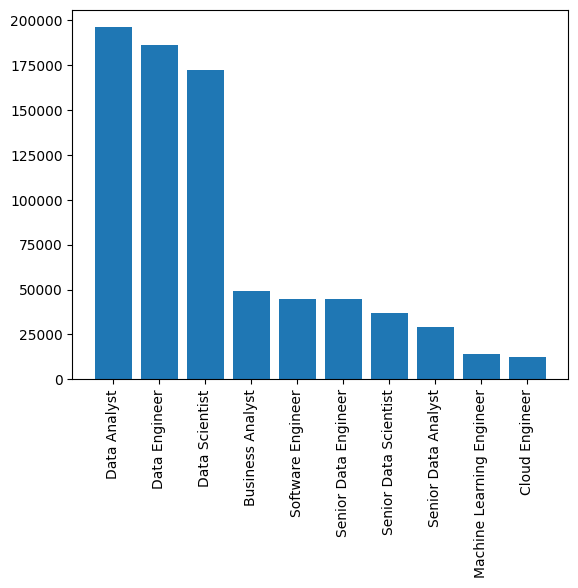

In [90]:
plt.bar(job_title_counts.index, job_title_counts.values)
plt.xticks(rotation=90, ha="center") #ha = "right", ha = "left"
#tight_layout ayuda a que los textos no se corten si son muy largos
#plt.tight_layout()
plt.show()

###Title

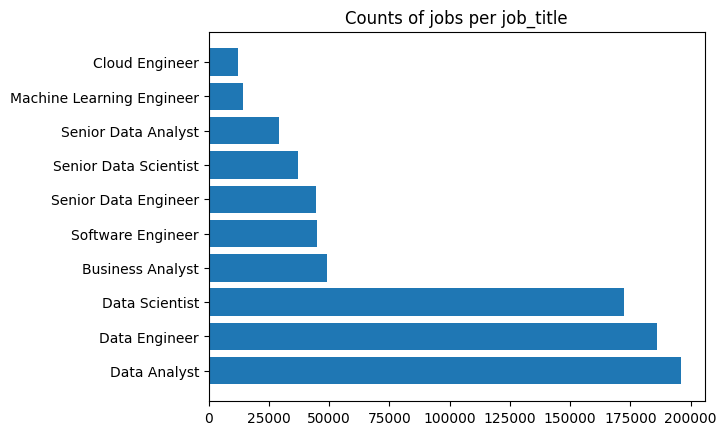

In [75]:
plt.barh(job_title_counts.index, job_title_counts.values)
plt.title("Counts of jobs per job_title")
plt.show()

###axislabels

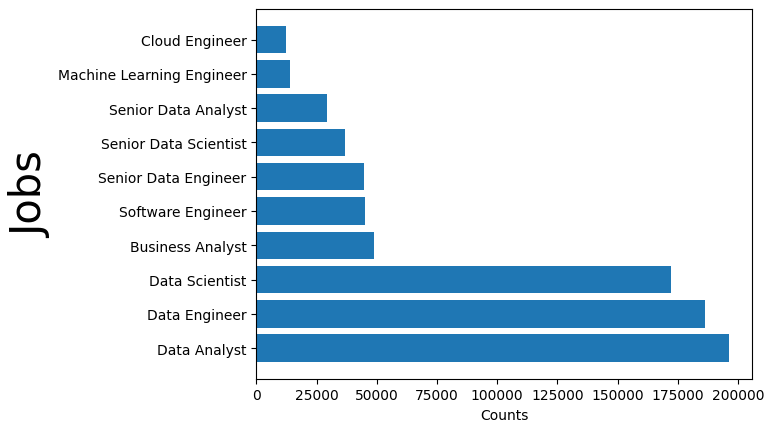

In [87]:
plt.barh(job_title_counts.index, job_title_counts.values)
plt.xlabel("Counts")
plt.ylabel("Jobs", size = 30)
plt.show()